#**Project Overview**

**The Problem**: Aircraft engine failures can lead to costly maintenance, unexpected downtime, and serious operational risks.

**Solution :** Predictive maintenance aims to identify signs of engine degradation before failure occurs, allowing maintenance decisions to be made proactively.

**Goal :** In this project, I estimate the Remaining Useful Life (RUL) of aircraft engines using multivariate sensor time-series data from the **NASA C-MAPSS FD001** dataset.

**Dataset :** FD001 contains **100 training engines**, each run from a healthy state until failure, and **100 test engines** whose sensor histories are cut off at a random point before failure. Every engine reports **3 operating settings** and **21 sensor channels** (temperature, pressure etc.) one row per operating cycle(flight). All engines run under a single operating condition (sea level) and a single fault mode.

Project Overview

1- Library Setup
2- Dataset Loading
3- Initial Data Exploration
4- Data Cleaning - Removing Dead Sensors
5- Feature Engineering — Remaining Useful Life (RUL) Target
6- Exploratory Data Analysis — Visualizations
7- Feature Engineering
8- Feature Selection
9- Train / Validation Split
10- Feature Scaling
11- Sliding Window
12- PyTorch Dataset & DataLoader
13- Model Architecture — Long Short-Term Memory (LSTM)
14-Sanity Check — Single Batch Forward Pass
15- Hyperparameter Search
16- Model Training
17. Test Set Preparation
18- Test Set Evaluation
19 -Streamlit Dasboard



In [1]:
import sys
!{sys.executable} -m pip install torch pandas numpy scikit-learn matplotlib seaborn joblib streamlit plotly

Defaulting to user installation because normal site-packages is not writeable


##**1- Library Setup**
All libraries used anywhere in this notebook are imported once, up front.

In [2]:
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import RobustScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


## **2- Dataset Loading**
The raw C-MAPSS files have no header row, so column names are assigned manually: **engine unit**, **cycle number**, **3 operating settings**, and **21 sensor measurements**.

- **`train_df`:** Training dataset containing complete run-to-failure trajectories for 100 engines. Each engine includes its operating cycles and sensor measurements until failure.

- **`test_df`:** Test dataset containing truncated sensor trajectories for 100 engines. The data for each engine ends before failure, so the actual failure point is not directly observed in the test data.

- **`rul_df`:** Ground-truth Remaining Useful Life (RUL) values for the final observed cycle of each engine in the test dataset. These values indicate how many cycles remained until failure after the last recorded test cycle.

In [3]:
col_names = ["unit", "cycle", "op_setting_1", "op_setting_2", "op_setting_3"] + [f"sensor_{i}" for i in range(1, 22)]

train_df = pd.read_csv("data/train_FD001.txt", sep=r"\s+", header=None)
train_df.columns = col_names

test_df = pd.read_csv("data/test_FD001.txt", sep=r"\s+", header=None)
test_df.columns = col_names

rul_df = pd.read_csv("data/RUL_FD001.txt", sep=r"\s+", header=None)



## **3- Initial Data Exploration**
Before any cleaning, get a feel for engine lifespans, dataset size, and data quality.

In [4]:
train_df

,unit,cycle,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
20627,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
20628,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
20629,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


### **3.1 Column Data Types**

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   unit          20631 non-null  int64  
 1   cycle         20631 non-null  int64  
 2   op_setting_1  20631 non-null  float64
 3   op_setting_2  20631 non-null  float64
 4   op_setting_3  20631 non-null  float64
 5   sensor_1      20631 non-null  float64
 6   sensor_2      20631 non-null  float64
 7   sensor_3      20631 non-null  float64
 8   sensor_4      20631 non-null  float64
 9   sensor_5      20631 non-null  float64
 10  sensor_6      20631 non-null  float64
 11  sensor_7      20631 non-null  float64
 12  sensor_8      20631 non-null  float64
 13  sensor_9      20631 non-null  float64
 14  sensor_10     20631 non-null  float64
 15  sensor_11     20631 non-null  float64
 16  sensor_12     20631 non-null  float64
 17  sensor_13     20631 non-null  float64
 18  sensor_14     20631 non-nu

Since everything is already **float** or **int**, **no dtype conversion is needed** before scaling or feeding this data into the model.

### **3.2 Missing Value Check**

In [6]:
print("Missing Values in Train:", train_df.isnull().sum().sum())
print("Missing Values in Test:", test_df.isnull().sum().sum())

Missing Values in Train: 0
Missing Values in Test: 0


A quick check for missing values across both datasets. **Both train_df and test_df** come back with **0 missing values** — this is expected, since C-MAPSS is a simulated dataset with no sensor dropouts or logging gaps, so **no imputation or row-dropping is needed** before moving forward.

### **3.3 Dimensionality Check**

In [7]:
print(f'Training Data Shape: {train_df.shape}')
print(f'Testing Data Shape:  {test_df.shape}')
print(f'RUL File Shape:      {rul_df.shape}')
# Check the ratio of testing data
print(f"Percentage of Testing Data: {len(test_df)/(len(train_df)+len(test_df)):.2%}")

Training Data Shape: (20631, 26)
Testing Data Shape:  (13096, 26)
RUL File Shape:      (100, 1)
Percentage of Testing Data: 38.83%


The training set contains **20,631** rows and the test set **13,096** rows, both with **26 columns** (unit, cycle, 3 operating settings, and 21 sensors — before any columns are dropped). The RUL file has exactly **100** rows, one ground-truth value per test engine.

Note that the **~39% test-row ratio** reflects cycles, not engines — **both** train and test contain **100 engines each**, but the test trajectories are truncated before failure, so they contain fewer cycles per engine on average than the full run-to-failure training trajectories.

### **3.4 Target & Life Cycle Analysis**

Grouping the training dataset by `unit` and calculate the maximum `cycle` value to determine the **total operational lifespan (Run-to-Failure)** for each engine.


In [8]:
# checking first 10 engines lifespan
cycles_per_unit = train_df.groupby('unit')['cycle'].max()
print(cycles_per_unit.head(10))

unit
1     192
2     287
3     179
4     189
5     269
6     188
7     259
8     150
9     201
10    222
Name: cycle, dtype: int64


In [9]:
cycles_per_unit.describe()

count    100.000000
mean     206.310000
std       46.342749
min      128.000000
25%      177.000000
50%      199.000000
75%      229.250000
max      362.000000
Name: cycle, dtype: float64

Distribution of engine lifespans (in cycles) across the 100 training engines — ranging from **128** to **362** cycles, with a mean of ~**206** and a median of **199**.

### **3.5 Histogram of life cycles**

Text(0.5, 1.0, 'Distribution of Engine Lifespans')

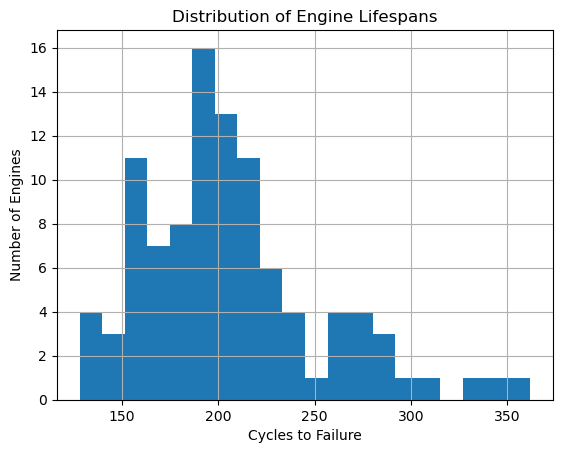

In [10]:
cycles_per_unit.hist(bins=20)
plt.xlabel("Cycles to Failure")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifespans")

The histogram shows a **right-skewed distribution**: most engines fail between roughly **150 and 225 cycles**, with the largest concentration around 175–225 cycles. A smaller tail of longer-lived engines extends out to 350+ cycles, pulling the mean **(206)** above the median **(199)**.

This spread is exactly why a single fixed RUL cutoff needs care — a healthy engine's sensor readings look similar whether it has 200 or 350 cycles left, so **treating those large RUL values** differently **doesn't help the model**.

## **4- Data Cleaning - Removing Dead Sensors**
If a sensor's value **never changes**, it has **nothing useful** to **teach** the model — so these constant columns are dropped from both train and test sets.

In [11]:
# Find sensors with only one unique value — they never change, so they're useless
constant_features = [col for col in train_df.columns if train_df[col].nunique() <= 1]

print(f'Dead/Constant Sensors identified: {constant_features}')
print(f'Number of Dead Sensors: {len(constant_features)} sensors.')

Dead/Constant Sensors identified: ['op_setting_3', 'sensor_1', 'sensor_5', 'sensor_10', 'sensor_16', 'sensor_18', 'sensor_19']
Number of Dead Sensors: 7 sensors.


In [12]:
# Drop those constant columns from both train and test sets
train_df.drop(columns=constant_features, inplace=True)
test_df.drop(columns=constant_features, inplace=True)

print(f"New Training Shape: {train_df.shape}")

New Training Shape: (20631, 19)


These 7 columns are **constant** because FD001 runs under **a single operating condition** (sea level) and **a single fault mode** — so op_setting_3 never varies, and several sensors (sensor_1, sensor_5, sensor_10, sensor_16, sensor_18, sensor_19) stay essentially flat regardless of engine degradation.

## **5- Feature Engineering — Remaining Useful Life (RUL) Target**

Since each training engine runs until it fails, **RUL at any cycle is** just: **how many cycles are left** until that engine's last recorded cycle.

In [13]:
# Find each engine's last (largest) cycle value and put it in its own table
max_cycle_table = train_df.groupby('unit')['cycle'].max().reset_index()

# Rename the new column to 'max_of_unit' to avoid confusion
max_cycle_table.columns = ['unit', 'max_of_unit']

In [14]:
# Merge the main table with the max-cycle table
train_df = train_df.merge(max_cycle_table, on='unit', how='left')
train_df

,unit,cycle,op_setting_1,op_setting_2,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,max_of_unit
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,192
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,192
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,192
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,192
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,192
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,-0.0004,-0.0003,643.49,1597.98,1428.63,21.61,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,200
20627,100,197,-0.0016,-0.0005,643.54,1604.50,1433.58,21.61,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,200
20628,100,198,0.0004,0.0000,643.42,1602.46,1428.18,21.61,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,200
20629,100,199,-0.0011,0.0003,643.23,1605.26,1426.53,21.61,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,200


In [15]:
# RUL = Max Cycle - Current Cycle
train_df['RUL'] = train_df['max_of_unit'] - train_df['cycle']

# Drop the 'max_of_unit' helper column now that we're done with it
train_df = train_df.drop(columns=['max_of_unit'])

# Check the first 10 rows
train_df[['unit', 'cycle', 'RUL']].head(10)

,unit,cycle,RUL
0,1,1,191
1,1,2,190
2,1,3,189
3,1,4,188
4,1,5,187
5,1,6,186
6,1,7,185
7,1,8,184
8,1,9,183
9,1,10,182


As cycle increases, RUL decreases by the same amount — this confirms the calculation is working as expected: the engine gets one cycle closer to failure, so it has one fewer cycle remaining. This **RUL column** is exactly the **target variable** the **model will learn to predict**.

## **6- Exploratory Data Analysis — Visualizations**

### **6.1 Justifying the Piecewise Linear RUL (RUL = 125 Breakpoint)**


Using the raw, uncapped RUL as the model's target is a problem: in the **early stage** of an engine's life, sensor **readings stay** essentially **flat**, so an engine with 300 cycles left looks almost identical to one with 200 cycles left. so large RUL values carry little useful signal. **A piecewise linear RUL** fixes this by treating all "healthy" cycles as one constant value.

To decide where the breakpoint should sit, I plot the **3 proof sensors** for a **sample of 10 engines** (every 10th unit) **against raw RUL** (x-axis reversed: healthy → failing), with shaded zones and a dashed line **at RUL = 125** — if the traces are flat before the line and trend clearly after it, that confirms 125 is the right cutoff.



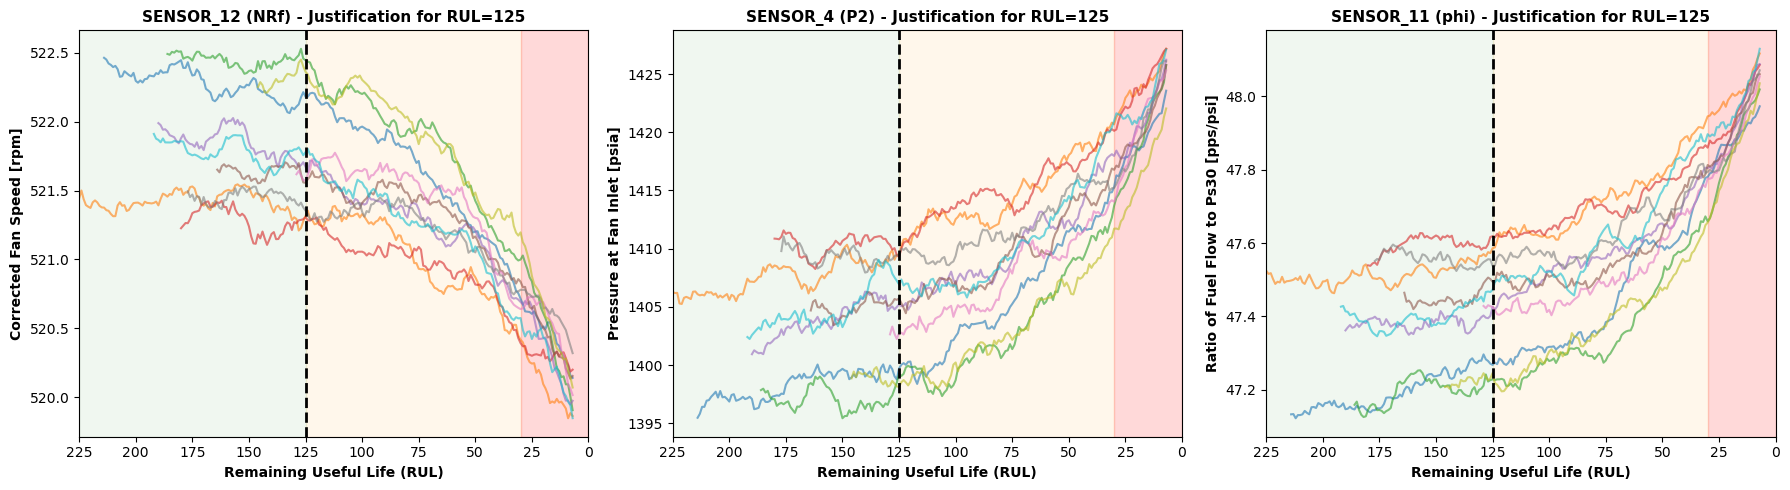

In [16]:
# The 3 sensors used as proof
proof_sensors = ['sensor_12', 'sensor_4', 'sensor_11']

# Short code, full name, and unit for each proof sensor (used in titles/labels below)
sensor_labels = {
    'sensor_12': ("NRf", "Corrected Fan Speed", "rpm"),
    'sensor_4': ("P2", "Pressure at Fan Inlet", "psia"),
    'sensor_11': ("phi", "Ratio of Fuel Flow to Ps30", "pps/psi")
}

# Create a figure with 1 row and 3 columns — one subplot per sensor
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Sample every 10th engine (10 out of 100) to keep the plot readable
units_to_plot = [u for u in train_df['unit'].unique() if u % 10 == 0]

# Loop over the 3 proof sensors, one subplot at a time
for i, col in enumerate(proof_sensors):
    ax = axes[i]

    # Plot the sensor data
    for u in units_to_plot:
        # Get this engine's data
        unit_data = train_df[train_df['unit'] == u]
        # Smooth the sensor readings with a rolling average to reduce noise
        smoothed = unit_data[col].rolling(window=15, center=True).mean()
        # Plot smoothed sensor values against RUL, one line per engine
        ax.plot(unit_data['RUL'], smoothed, linewidth=1.5, alpha=0.6)

    # Fix the x-axis range from 225 down to 0, so it reads "healthy -> failing" left to right
    ax.set_xlim(225, 0)

    # 1. RUL = 125 breakpoint line
    ax.axvline(x=125, color='black', linestyle='--', linewidth=2, label='RUL Cap (125)')

    # 2. Zone highlights
    # Shade the region where RUL > 125 (healthy / flat zone)
    ax.axvspan(225, 125, color='green', alpha=0.06, label='Healthy / Flat Zone (RUL > 125)')
    # Shade the region where RUL is between 30 and 125 (degradation zone)
    ax.axvspan(125, 30, color='orange', alpha=0.08, label='Degradation Zone (30 <= RUL <= 125)')
    # Shade the region where RUL < 30 (critical zone, close to failure)
    ax.axvspan(30, 0, color='red', alpha=0.15, label='Critical Zone (RUL < 30)')

    # Look up this sensor's short code, full name, and unit for labeling
    short_code, full_name, unit = sensor_labels.get(col, (col, col, ""))

    # Set the subplot title, x-axis label, and y-axis label
    ax.set_title(f"{col.upper()} ({short_code}) - Justification for RUL=125", fontsize=11, fontweight='bold')
    ax.set_xlabel("Remaining Useful Life (RUL)", fontsize=10, fontweight='bold')
    ax.set_ylabel(f"{full_name} [{unit}]" if unit else full_name, fontsize=10, fontweight='bold')

# Adjust spacing so subplots and labels don't overlap, then display the figure
plt.tight_layout()
plt.show()

As the plots above show, all three **sensors stay** essentially **flat** **while RUL is above ~125 cycles**, then **start trending clearly as the engine approaches failure**. This confirms that **RUL = 125** is a reasonable breakpoint: healthy cycles beyond this point don't carry extra useful signal, so capping RUL at 125 lets the model focus its capacity on the region where sensor behavior actually reflects degradation.

### **6.2 Degradation Path for Every Remaining Sensor**

Here, the same idea is extended to every sensor still present in `train_df`. For each sensor, a smoothed trace is plotted against RUL for a s**ample of 10 engines**, laid out in a grid so all sensors can be compared side by side at once. **The goal** is to see, across the full feature set, **which sensors show a clear, consistent trend** as engines **approach failure** (informative for the model) and **which stay flat** **or noisy** throughout (little to no useful signal).

The focus is on what happens after RUL drops below 125 — as shown earlier, this is where degradation patterns actually start to appear. The **red-shaded region** marks **RUL < 30**, the "**dangerous zone**" where the engine is close to failure. The goal is to see, across the full feature set, which sensors show a clear, consistent trend as engines approach failure (**informative for the model**) and **which stay flat or noisy throughout** (little to no useful signal).

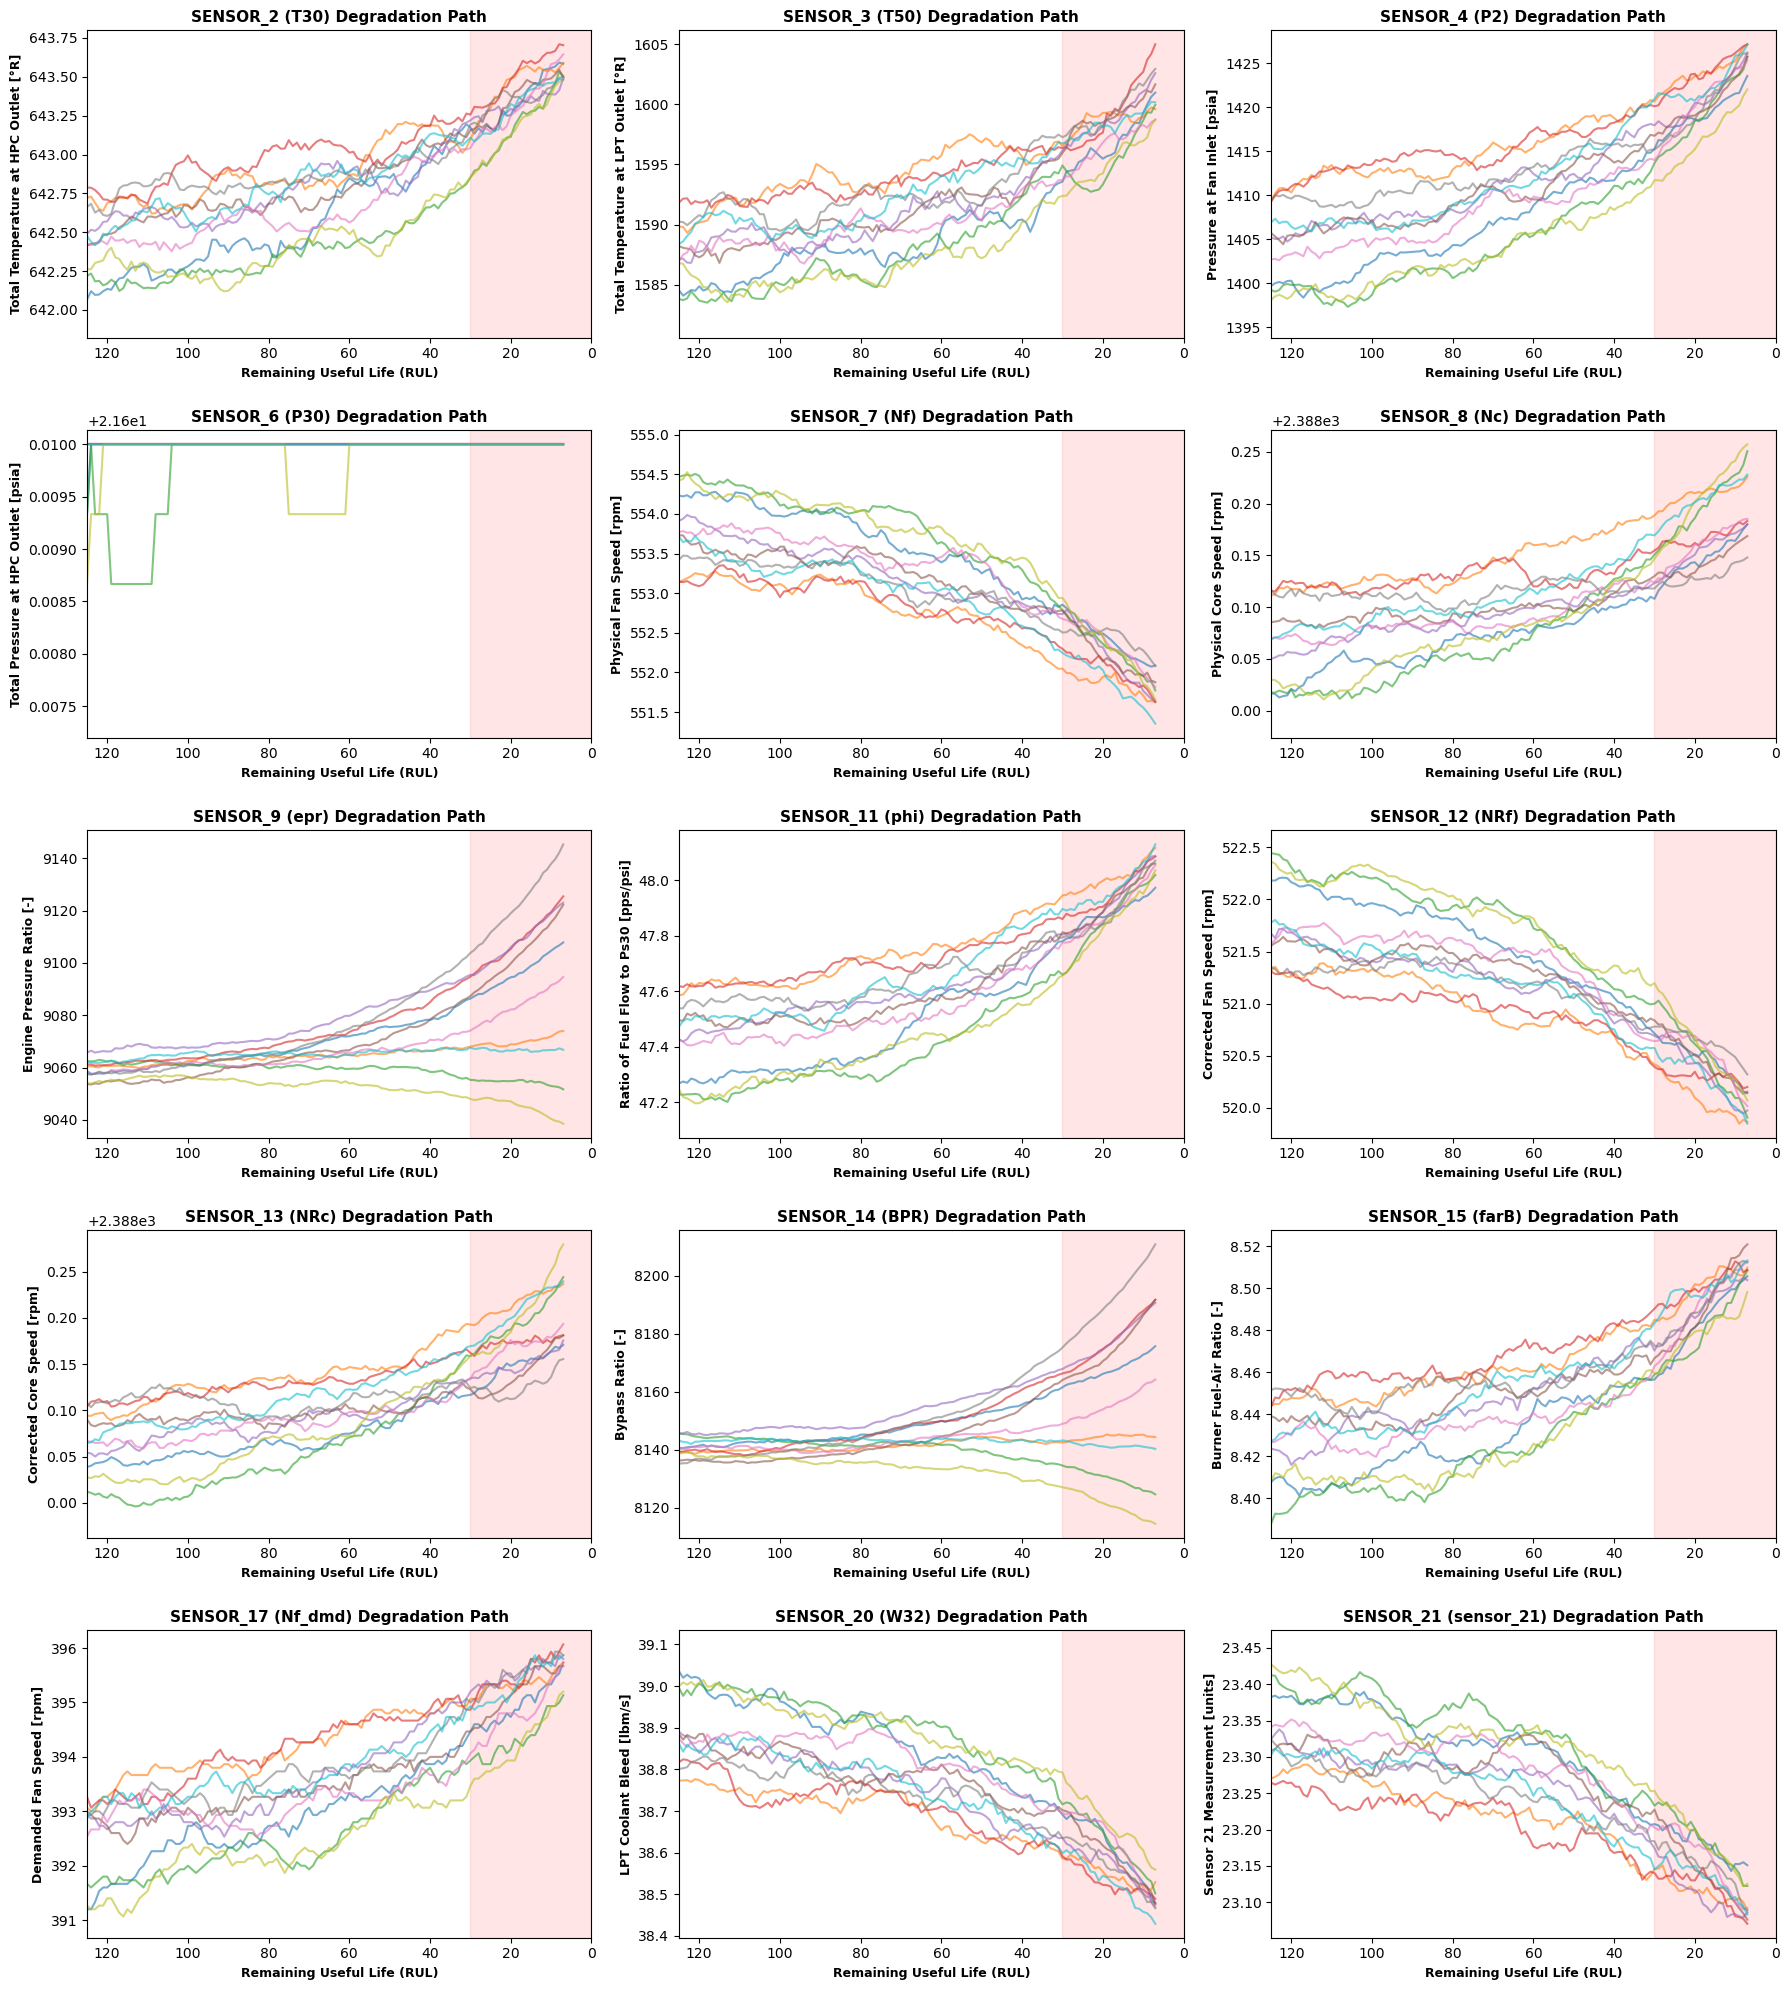

In [17]:
# 1. Sensor technical definitions and units
sensor_labels = {
    'sensor_2': ("T30", "Total Temperature at HPC Outlet", "°R"),
    'sensor_3': ("T50", "Total Temperature at LPT Outlet", "°R"),
    'sensor_4': ("P2", "Pressure at Fan Inlet", "psia"),
    'sensor_6': ("P30", "Total Pressure at HPC Outlet", "psia"),
    'sensor_7': ("Nf", "Physical Fan Speed", "rpm"),
    'sensor_8': ("Nc", "Physical Core Speed", "rpm"),
    'sensor_9': ("epr", "Engine Pressure Ratio", "-"),
    'sensor_11': ("phi", "Ratio of Fuel Flow to Ps30", "pps/psi"),
    'sensor_12': ("NRf", "Corrected Fan Speed", "rpm"),
    'sensor_13': ("NRc", "Corrected Core Speed", "rpm"),
    'sensor_14': ("BPR", "Bypass Ratio", "-"),
    'sensor_15': ("farB", "Burner Fuel-Air Ratio", "-"),
    'sensor_17': ("Nf_dmd", "Demanded Fan Speed", "rpm"),
    'sensor_20': ("W32", "LPT Coolant Bleed", "lbm/s"),
    'sensor_21': ("sensor_21", "Sensor 21 Measurement", "units")
}

# 2. Auto-detect which sensor columns are still present in train_df
sensor_cols = [col for col in train_df.columns if col.startswith('sensor_')]  # grab all sensor_* columns
sensor_cols = sorted(sensor_cols, key=lambda x: int(x.split('_')[1]))         # sort them numerically (sensor_2, sensor_3, ... not alphabetically)

# 3. Dynamic grid layout (3 plots per row)
n_sensors = len(sensor_cols)               # how many sensors we need to plot
ncols = 3                                  # fixed at 3 plots per row
nrows = int(np.ceil(n_sensors / ncols))    # enough rows to fit all sensors, rounded up

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18, 4 * nrows))  # create the grid of subplots
axes = axes.flatten()                                                        # flatten to a 1D list so we can index it with a simple loop counter

# Select every 10th engine
units_to_plot = [u for u in train_df['unit'].unique() if u % 10 == 0]  # sample 10 engines out of 100 to keep the plots readable

# 4. Plotting loop for every sensor present in train_df
for i, col in enumerate(sensor_cols):   # loop through each sensor, i = subplot index, col = sensor column name
    ax = axes[i]                        # select this sensor's subplot

    for u in units_to_plot:                                            # loop through each sampled engine
        unit_data = train_df[train_df['unit'] == u]                    # get this engine's rows
        smoothed = unit_data[col].rolling(window=15, center=True).mean()  # smooth the sensor readings to reduce noise
        ax.plot(unit_data['RUL'], smoothed, linewidth=1.5, alpha=0.6)  # plot smoothed sensor values against RUL

    ax.set_xlim(125, 0)                            # fix x-axis to RUL 125 -> 0 (the degradation zone)
    ax.axvspan(30, 0, color='red', alpha=0.1)     # shade the RUL < 30 "dangerous zone" in red
    ...

    short_code, full_name, unit = sensor_labels.get(col, (col, col, ""))  # look up this sensor's short code, full name, and unit

    ax.set_title(f"{col.upper()} ({short_code}) Degradation Path", fontsize=11, fontweight='bold')  # subplot title
    ax.set_xlabel("Remaining Useful Life (RUL)", fontsize=9, fontweight='bold')                                          # x-axis label
    ax.set_ylabel(f"{full_name} [{unit}]" if unit else full_name, fontsize=9, fontweight='bold')                         # y-axis label

# Hide any unused empty axes (in case the grid has more cells than sensors)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()  # adjust spacing so titles/labels don't overlap
plt.show()           # display the figure

Except for `sensor_6`, **every sensor shows a clear rise or fall** in value** as the engine approaches failure** — this **degradation signal** is exactly what will **help the model learn to predict RUL**.

### **6.3 Sensor Correlation with RUL**
A quick, ranked check of **how strongly each sensor correlates with RUL** — sensors near +1/-1 move consistently with RUL and are likely useful features, while sensors near 0 carry little linear signal.

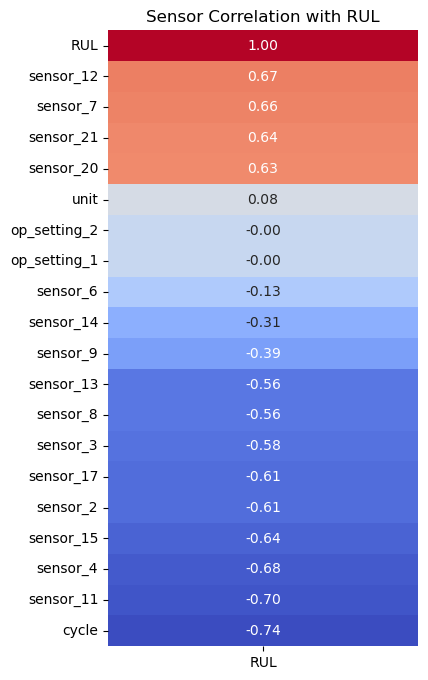

In [18]:
# 1. Compute the correlation matrix and sort by correlation with RUL
corr_matrix = train_df.corr()    # compute pairwise correlation between all numeric columns
rul_corr = corr_matrix[['RUL']].sort_values(by='RUL', ascending=False)  # keep only the RUL column, sort sensors from most to least correlated

# 2. Draw the heatmap
plt.figure(figsize=(4, 8))     # tall, narrow figure since we only have 1 column of values
sns.heatmap(rul_corr, annot=True, cmap='coolwarm', fmt=".2f", cbar=False)  # annot=True shows the correlation number in each cell, coolwarm colors negative vs positive

# 3. Title and labels
plt.title("Sensor Correlation with RUL")
plt.show()

The strongest correlations belong to `sensor_11` (-0.70) and `sensor_4` (-0.68) on the negative side, and `sensor_12` (0.67) and `sensor_7` (0.66) on the positive side — these are the sensors most worth watching, and they match exactly what the degradation-path plots showed earlier: **negatively-correlated sensors rise as the engine approaches failure (RUL drops), while positively-correlated ones fall.**

A few sanity checks confirm the data makes sense: `unit` (0.08) and `op_setting_1`/`op_setting_2` (~0.00) **show almost no correlation with RU**L, as expected — engine ID and operating settings shouldn't carry any degradation signal in FD001. `cycle` itself is strongly correlated (-0.74), which isn't surprising since RUL is directly derived from the cycle count.

At the weak end, `sensor_6` (-0.13) confirms what was already visible in the degradation-path grid — a flat, quantized signal with almost **no relationship to RUL** — so **it will be dropped** from the feature set.

### **6.4 Outlier Analysis**

Before deciding **how to scale** the features, it's worth checking how heavy-tailed the sensor distributions actually are. Boxplots are drawn for two heavily-skewed sensors — `sensor_9` and `sensor_14` — to visualize how many points fall outside the interquartile range (the "whiskers"). This directly informs the scaler choice in the next step: **if outliers are this common**, a standard mean/variance scaler would be distorted by them, so a more **robust**, outlier-resistant scaling method is needed instead.

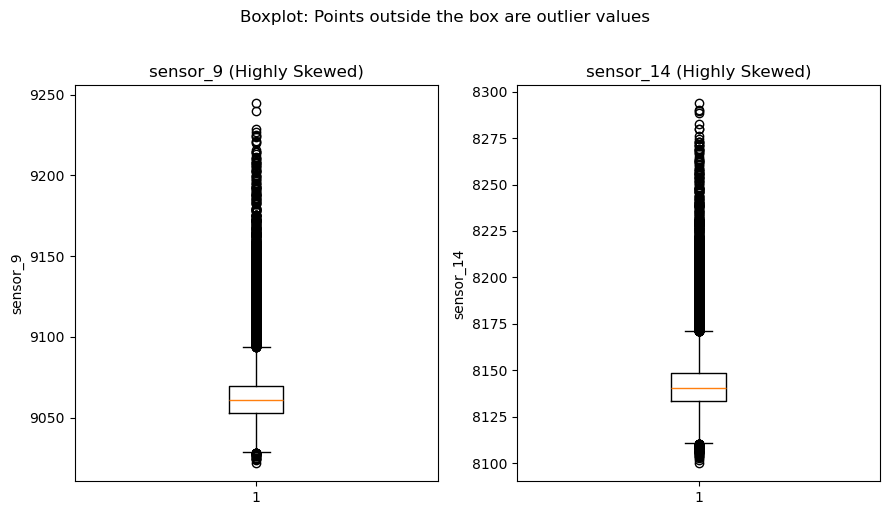

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(9, 5))  # 1 row, 2 columns — one subplot per sensor

# Loop through the 2 sensors and their subplot titles together
for ax, col, title in zip(axes, ["sensor_9", "sensor_14"],
                           ["sensor_9 (Highly Skewed)", "sensor_14 (Highly Skewed)"]):
    ax.boxplot(train_df[col], vert=True)  # draw a vertical boxplot for this sensor
    ax.set_title(title)                   # subplot title
    ax.set_ylabel(col)                    # y-axis label = sensor name

plt.suptitle("Boxplot: Points outside the box are outlier values", y=1.02)  # overall figure title
plt.tight_layout()  # adjust spacing so subplots/labels don't overlap
plt.show()           # display the figure

Both sensors show dense clusters of outlier points well outside the whiskers, confirming heavy-tailed distributions — this is why **`RobustScaler`** (median/IQR-based) is used instead of a standard scaler in the next step.

## **7- Feature Engineering**

### **Applying the RUL Cap (RUL = 125)**

RUL is capped at 125 so **the model can focus on learning the region where **degradation** is actually visible**, instead of wasting capacity on flat, uninformative "healthy" cycles.

In [20]:
RUL_THRESHOLD = 125                                          # the breakpoint chosen based on the EDA above
train_df['RUL'] = train_df['RUL'].clip(upper=RUL_THRESHOLD)  # cap any RUL value above 125 down to 125
train_df['RUL'].describe()                                   # check the new distribution of RUL after capping

count    20631.000000
mean        86.829286
std         41.673699
min          0.000000
25%         51.000000
50%        103.000000
75%        125.000000
max        125.000000
Name: RUL, dtype: float64

##  **8- Feature Selection**

### **Dropping Redundant Features**

Based on the correlation and degradation-path analysis above, **`sensor_6`** (near-zero correlation, flat/quantized signal) and the two remaining operating settings **`op_setting_1`/`op_setting_2`** (near-zero correlation, expected since FD001 runs under a single operating condition) are dropped — **they add noise rather than useful signal for the model**.

In [21]:
train_df.drop(columns=['sensor_6', 'op_setting_1', 'op_setting_2'], inplace=True)
test_df.drop(columns=['sensor_6', 'op_setting_1', 'op_setting_2'], inplace=True, errors='ignore')

In [22]:
train_df

,unit,cycle,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,641.82,1589.70,1400.60,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,125
1,1,2,642.15,1591.82,1403.14,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,125
2,1,3,642.35,1587.99,1404.20,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,125
3,1,4,642.35,1582.79,1401.87,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,125
4,1,5,642.37,1582.85,1406.22,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,125
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20626,100,196,643.49,1597.98,1428.63,551.43,2388.19,9065.52,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,4
20627,100,197,643.54,1604.50,1433.58,550.86,2388.23,9065.11,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,3
20628,100,198,643.42,1602.46,1428.18,550.94,2388.24,9065.90,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,2
20629,100,199,643.23,1605.26,1426.53,550.68,2388.25,9073.72,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,1


## **9- Train / Validation Split**
Splits the training engines into a train and validation set. **`GroupShuffleSplit`** is used instead of a regular random split so that each engine (`unit`) — and all of its cycles — stays entirely on one side, **preventing any leakage between train and validation**.

In [23]:
# Split into 80% train / 20% validation without breaking up engines (grouped by unit)
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=123)  # n_splits=1 -> just one split; test_size=0.2 -> 20% goes to validation; random_state -> reproducible split

train_idx, val_idx = next(gss.split(train_df, groups=train_df['unit']))  # generate the split: groups=unit ensures whole engines go to one side

train_split = train_df.iloc[train_idx].copy()  # select the training rows using train_idx
val_split = train_df.iloc[val_idx].copy()      # select the validation rows using val_idx

A quick sanity check — lists the unique engine IDs that ended up in `val_split`. This confirms the `GroupShuffleSplit` worked as expected: roughly 20 engines (≈20% of the 100 training engines) should appear here, and none of these unit numbers should also show up in `train_split`.

In [24]:
print (val_split['unit'].unique())  # sanity check: which engines ended up in validation (should be ~20 of the 100)
print(f"There are {len(val_split['unit'].unique())} engines in validation")

[ 1  5  6  9 24 25 29 39 43 51 57 61 64 66 71 76 77 78 82 83]
There are 20 engines in validation


## **10- Feature Scaling**
Since the EDA boxplot (6.4) showed **heavy outliers** in several sensors, **`RobustScaler`** (median/IQR-based) is used here instead of a standard scaler, **since it's much less sensitive to extreme values**.






In [25]:
# unit, cycle, and RUL should not be scaled - only sensor columns are scaled
feature_cols = [c for c in train_split.columns if c not in ['unit', 'cycle', 'RUL']]  # list of columns to scale (everything except unit, cycle, RUL)

scaler = RobustScaler()  # create the scaler (median/IQR-based)

train_split[feature_cols] = scaler.fit_transform(train_split[feature_cols])   # fit ONLY on train (learns median/IQR from train), then scale train
val_split[feature_cols] = scaler.transform(val_split[feature_cols])           # same scaler, transform only (no re-fitting) — applies train's stats to validation

train_split[feature_cols].describe().loc[['min','max']]  # sanity check: see the new min/max range of each scaled column

,sensor_2,sensor_3,sensor_4,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
min,-2.089552,-2.384807,-1.913549,-2.618644,-2.111111,-2.349527,-1.861111,-2.836735,-2.000000,-2.814866,-2.232,-2.5,-2.875,-2.800419
max,2.805970,3.327522,2.766417,2.228814,4.777778,10.564038,2.805556,1.948980,5.111111,10.282863,2.906,3.5,2.500,2.213538


Most sensors scale into a similar range (~-2 to 5), but `sensor_9` and `sensor_14` still show large maxes (10.56, 10.28) — confirming the heavy outliers seen in the earlier boxplot. **`RobustScaler`** doesn't remove these outliers, it just **keeps them from distorting the scale** for the rest of the sensors.

## **11- Sliding Window**

Up to this point, the data is still row-by-row — one row per engine per cycle. But an **LSTM (Long short-term memory)** doesn't take a single row as input; it needs a **sequence** of consecutive cycles, so it can learn how sensor readings evolve over time, not just their value at one instant.

This is done with a sliding window of size **`WINDOW_SIZE = 30`**: for each engine, every 30 consecutive cycles are grouped into one training example, labeled with the RUL at the last cycle in that window.

Each window shifts forward by 1 cycle and is labeled with the RUL at its last cycle — this repeats across every engine to generate the full set of training windows.

Cycles:   [1 2 3 4 5 ... 28 29 30] 31 32 ...
           └────── **Window 1**──────┘
                                → predicts RUL at cycle 30

Cycles:    1 [2 3 4 5 ... 29 30 31] 32 ...
              └────── **Window 2** ──────┘
                                    → predicts RUL at cycle 31


In [26]:
WINDOW_SIZE = 30  # number of consecutive cycles in each input sequence

# TRAIN: generate every possible window for each engine (acts as data augmentation)
def create_train_windows(df, feature_cols, window_size=WINDOW_SIZE):  # df = train_split, feature_cols = scaled sensor/setting columns
    X, y = [], []  # X will hold the windows (sequences), y will hold their RUL labels
    for unit_id, g in df.groupby('unit'):  # groups by engine unit (100 total); g holds each group as a separate DataFrame
        g = g.sort_values('cycle')       # just to guarantee correct chronological order
        feats = g[feature_cols].values   # convert this engine's sensor data to a numpy array, since the LSTM only works with arrays
        ruls = g['RUL'].values           # convert the RUL values in this group to a numpy array
        n = len(g)                       # e.g. the first engine's DataFrame has 287 rows and 14 columns, so n=287, and so on for each engine
        for end in range(window_size, n + 1):    # e.g. for engine 2, range(30, 288); end goes from 30 to 288, inclusive of 287
            X.append(feats[end-window_size:end])   # feats[0:30], then feats[1:31], then feats[2:32], and so on
            y.append(ruls[end-1])              # this is ruls[29], then ruls[30], and so on
    return np.array(X), np.array(y)  # convert the lists of windows/labels into numpy arrays

# VALIDATION: cut each engine at a random point (mimics a realistic test scenario;
# otherwise it would always be the trivial "last row = RUL 0" case)
def create_val_windows(df, feature_cols, window_size=WINDOW_SIZE, seed=42):  # seed makes the random cut reproducible
    X, y = [], []  # X will hold the single window per engine, y will hold its RUL label
    for unit_id, g in df.groupby('unit'):  # loop through each validation engine
        g = g.sort_values('cycle')  # ensure chronological order
        feats = g[feature_cols].values  # this engine's sensor data as a numpy array
        ruls = g['RUL'].values  # this engine's RUL values as a numpy array
        n = len(g)  # total number of cycles for this engine
        rng = np.random.RandomState(seed + int(unit_id))   # a NumPy random number generator seeded per engine for reproducibility
        cut = rng.randint(window_size, n + 1)               # random cut point
        X.append(feats[cut-window_size:cut])  # take the 30 cycles ending at the random cut point
        y.append(ruls[cut-1])  # label = RUL at that cut point
    return np.array(X), np.array(y)  # convert to numpy arrays

X_train, y_train = create_train_windows(train_split, feature_cols)  # build all training windows
X_val, y_val = create_val_windows(val_split, feature_cols)  # build one window per validation engine

print("X_train shape:", X_train.shape, " y_train shape:", y_train.shape)  # should be (num_windows, 30, num_features) and (num_windows,)
print("X_val shape:", X_val.shape, " y_val shape:", y_val.shape)  # should be (num_val_engines, 30, num_features) and (num_val_engines,)

X_train shape: (14256, 30, 14)  y_train shape: (14256,)
X_val shape: (20, 30, 14)  y_val shape: (20,)


Sliding windows produced **14,256 training sequences** (all possible 30-cycle windows across the 80 training engines), **each shaped as 30 cycles × 14 features**. Validation has exactly 20 sequences — one per validation engine, matching the 20 engines in `val_split` — since only one random window is taken per engine there instead of every possible one.

## **12-  PyTorch Dataset & DataLoader**

So far, **`X_train`/`y_train` and `X_val`/`y_val`** are plain **numpy arrays**. PyTorch doesn't train directly on numpy arrays — it needs data wrapped in its own `Dataset`/`DataLoader` classes, which handle a few things numpy doesn't:

- **`Dataset`**: a standard wrapper that converts the numpy arrays into tensors and tells PyTorch how many samples exist and how to fetch a single one (`__len__` and `__getitem__`). This gives PyTorch a consistent interface to pull data from, regardless of where it originally came from.
- **`DataLoader`**: takes a `Dataset` and handles **batching** (grouping samples into batches of, say, 64, instead of feeding one window at a time — much faster and more stable for gradient updates) and **shuffling** (randomizing the order every epoch for training, so the model doesn't learn a fixed sequence of engines). Without shuffling, the model would repeatedly see engines in the same order and could pick up on that ordering instead of the actual sensor patterns.



In [27]:
class RULDataset(Dataset):  # custom Dataset wrapping our windowed numpy arrays
    def __init__(self, X, y):
        # convert numpy arrays to torch tensors
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        # tells PyTorch how many samples are in the dataset
        return len(self.X)

    def __getitem__(self, idx):
        # called when PyTorch requests the sample at index idx
        return self.X[idx], self.y[idx]


# create separate Dataset objects for train and validation
train_dataset = RULDataset(X_train, y_train)  # wraps the training windows/labels
val_dataset = RULDataset(X_val, y_val)        # wraps the validation windows/labels

# DataLoader: batching + shuffling for training
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)   # shuffle=True randomizes order each epoch
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)      # no need to shuffle validation, order doesn't matter

# sanity check: look at the shape of the first batch
X_batch, y_batch = next(iter(train_loader))   # pull one batch out of the loader to inspect it
print("X_batch shape:", X_batch.shape)        # should be (batch_size, window_size, n_features)
print("y_batch shape:", y_batch.shape)        # should be (batch_size,)

X_batch shape: torch.Size([64, 30, 14])
y_batch shape: torch.Size([64])


Confirms the DataLoader is working as expected: each **batch** contains **64 windows**, each **window** covering **30 cycles with 14 features** (`X_batch`), paired with 64 corresponding RUL labels (`y_batch`) — exactly the shape the LSTM expects as input.

---



## **13- Model Architecture —  Long Short-Term Memory (LSTM)**

This defines the model: an LSTM reads a 30-cycle window step by step, building up a memory of how the sensors changed over that window. At the end, that memory is passed through a linear layer that turns it into a single number — the predicted RUL.

In [28]:
class RULLSTM(nn.Module):                         # define our model, inheriting from PyTorch's base Module class
    def __init__(self, n_features, hidden_size=64, num_layers=1):
        super().__init__()                         # required PyTorch boilerplate to initialize the parent class
        self.lstm = nn.LSTM(
            input_size=n_features,      # number of features per cycle (14 in our case)
            hidden_size=hidden_size,    # internal "memory" size of the LSTM
            num_layers=num_layers,      # number of stacked LSTM layers
            batch_first=True            # input shape is (batch, window, features)
        )
        self.head = nn.Linear(hidden_size, 1)   # reduces the LSTM output to a single value (RUL)

    def forward(self, x):
        # x shape: (batch_size, window_size, n_features) -> e.g. (64, 30, 14)
        _, (h_n, c_n) = self.lstm(x)   # run the sequence through the LSTM; we only need the final hidden state
        # h_n shape: (num_layers, batch_size, hidden_size) -> (1, 64, 64)
        last_hidden = h_n[-1]              # last layer's memory at the final cycle -> (64, 64)
        rul_pred = self.head(last_hidden)  # (64, 64) -> (64, 1)
        return rul_pred.squeeze(-1)        # (64, 1) -> (64,), a more convenient flat vector

## **14-Sanity Check — Single Batch Forward Pass**
Before launching the full training loop, I run a single batch through the model to confirm the architecture is wired correctly — input and output shapes match expectations, and no errors are raised. This catches shape mismatches or type errors early, rather than discovering them minutes into a 100-epoch training run.

In [29]:
# build the model and test it on a single batch
model = RULLSTM(n_features=X_train.shape[2], hidden_size=64, num_layers=1)   # create the model instance with 14 input features

X_batch, y_batch = next(iter(train_loader))   # pull one batch from the DataLoader (features + true RUL labels)
pred = model(X_batch)                          # run a forward pass through the model
print("Prediction shape:", pred.shape)   # should be (64,)
print("Sample predictions (untrained, random):", pred[:5])   # weights are random at this point, so these values are meaningless — we're only checking the shape

Prediction shape: torch.Size([64])
Sample predictions (untrained, random): tensor([-0.0303, -0.0380,  0.0030, -0.0625, -0.0384], grad_fn=<SliceBackward0>)


The output shape matches expectations — **64 predictions, one per sample in the batch.** The predicted values are small and clustered together since the model is still untrained (random weights); this simply confirms the **architecture is wired correctly** before we move on to real training.

## **15- Hyperparameter Search**

Before committing to a final architecture, I run a small **grid search** over three hyperparameters: **hidden size** (the LSTM's memory capacity), **number of LSTM layers** (how many are stacked, allowing more complex temporal patterns to be learned), and **learning rate** (how large each weight update step is). Each configuration is trained from scratch and scored on the validation set — the test set is intentionally left untouched here, so it remains a fair, unbiased measure of final performance later.

In [30]:
def train_and_evaluate(hidden_size, num_layers, lr, epochs=20, seed=42):
    torch.manual_seed(seed)      # fix the random seed so every config starts from the same initial weights
    np.random.seed(seed)         # ...and any numpy-based randomness is also reproducible

    # X_train, y_train, X_val, y_val were already built in Section 12 — window_size is fixed at 30,
    # so there's no need to recreate them for every config
    loader = DataLoader(RULDataset(X_train, y_train), batch_size=64, shuffle=True)   # wrap the training windows in a DataLoader
    m = RULLSTM(n_features=len(feature_cols), hidden_size=hidden_size, num_layers=num_layers)   # build a fresh model with this config's architecture
    opt = optim.Adam(m.parameters(), lr=lr)   # optimizer, using this config's learning rate
    lf = nn.MSELoss()                          # loss function: mean squared error

    for epoch in range(epochs):   # shortened training loop (20 epochs) — just enough to compare configs quickly
        m.train()                 # training mode
        for xb, yb in loader:     # iterate over mini-batches
            opt.zero_grad()       # clear gradients from the previous step
            loss = lf(m(xb), yb)  # forward pass + compute loss
            loss.backward()       # backpropagate
            opt.step()            # update the weights

    m.eval()   # switch to evaluation mode
    with torch.no_grad():   # no gradient tracking needed during evaluation
        preds = m(torch.tensor(X_val, dtype=torch.float32)).numpy()   # evaluate on the VALIDATION set (test set stays untouched)
    return float(np.sqrt(np.mean((preds - y_val) ** 2)))   # return validation RMSE as a plain float


# the grid of hyperparameter combinations to try — varying hidden_size, num_layers, and lr one at a time
configs_to_try = [
    {"hidden_size": 32,  "num_layers": 1, "lr": 1e-3},
    {"hidden_size": 64,  "num_layers": 1, "lr": 1e-3},
    {"hidden_size": 128, "num_layers": 1, "lr": 1e-3},
    {"hidden_size": 64,  "num_layers": 1, "lr": 5e-4},
    {"hidden_size": 32,  "num_layers": 1, "lr": 5e-4},
]

results = []                        # will hold one result dict per config
for cfg in configs_to_try:
    val_rmse = train_and_evaluate(**cfg)   # train and evaluate a model with this config, scored on validation
    results.append({**cfg, "VAL_RMSE": round(val_rmse, 2)})   # store the config alongside its resulting validation RMSE
    print(cfg, "-> VAL_RMSE:", round(val_rmse, 2))   # print progress as each config finishes

results_table = pd.DataFrame(results).sort_values("VAL_RMSE").reset_index(drop=True)   # rank configs from best (lowest val RMSE) to worst
results_table

{'hidden_size': 32, 'num_layers': 1, 'lr': 0.001} -> VAL_RMSE: 18.04
{'hidden_size': 64, 'num_layers': 1, 'lr': 0.001} -> VAL_RMSE: 13.38
{'hidden_size': 128, 'num_layers': 1, 'lr': 0.001} -> VAL_RMSE: 15.57
{'hidden_size': 64, 'num_layers': 1, 'lr': 0.0005} -> VAL_RMSE: 16.23
{'hidden_size': 32, 'num_layers': 1, 'lr': 0.0005} -> VAL_RMSE: 35.77


,hidden_size,num_layers,lr,VAL_RMSE
0,64,1,0.0010,13.38
1,128,1,0.0010,15.57
2,64,1,0.0005,16.23
3,32,1,0.0010,18.04
4,32,1,0.0005,35.77


The best configuration is `hidden_size=64, num_layers=1, lr=0.001` (VAL_RMSE = 13.38).The `hidden_size=32, lr=0.0005` configuration performs far worse (VAL_RMSE = 35.77), likely because the combination of low model capacity and a slow learning rate leaves it underfit within just 20 epochs.

## **16- Model Training**

With **`hidden_size=64, num_layers=1, lr=0.001`** confirmed as the **best configuration** by the hyperparameter search, this trains the final model on the full training set using **early stopping** — if validation loss doesn't improve for a set number of epochs (patience=15), training stops automatically and the best-performing weights are kept, rather than training for a fixed number of epochs regardless of whether the model is still improving.

In [31]:
EPOCHS = 100    # maximum number of passes over the full training set
PATIENCE = 15   # validation set is small (~20 engines) and noisy, so we need patience - don't stop on a single bad epoch

best_val_loss = float('inf')   # track the lowest validation loss seen so far (start at infinity so the first epoch always beats it)
best_model_state = None        # will hold a snapshot of the model's weights at the best epoch
epochs_no_improve = 0          # counts consecutive epochs with no improvement, for early stopping

train_loss_history = []   # store training loss per epoch, for plotting the learning curve later
val_loss_history = []     # store validation loss per epoch, same purpose

torch.manual_seed(42)      # fix the random seed for reproducible weight initialization
np.random.seed(42)         # ...and reproducible shuffling

# Re-create the model from scratch for a clean start (don't carry over the earlier sanity-check weights)
model = RULLSTM(n_features=X_train.shape[2], hidden_size=64, num_layers=1)   # winning config from the hyperparameter search
optimizer = optim.Adam(model.parameters(), lr=1e-3)   # Adam optimizer, updates the model's weights during training
loss_fn = nn.MSELoss()   # mean squared error - measures how far predictions are from true RUL values

for epoch in range(EPOCHS):   # loop over epochs, one full pass through the training data each time
    model.train()              # switch model to training mode
    train_loss_sum = 0         # accumulate total training loss across all batches this epoch
    for X_batch, y_batch in train_loader:   # iterate over mini-batches of training windows
        optimizer.zero_grad()               # clear gradients from the previous batch
        pred = model(X_batch)               # forward pass: get predictions for this batch
        loss = loss_fn(pred, y_batch)       # compute how wrong the predictions are
        loss.backward()                     # backpropagate: compute gradients
        optimizer.step()                    # update the model's weights using those gradients
        train_loss_sum += loss.item() * len(X_batch)   # add this batch's loss, weighted by batch size (for a correct average later)
    train_loss_avg = train_loss_sum / len(train_dataset)   # average training loss over the whole epoch

    model.eval()          # switch model to evaluation mode
    val_loss_sum = 0       # accumulate total validation loss across all batches this epoch
    with torch.no_grad():   # no gradient tracking needed during evaluation - saves memory and compute
        for X_batch, y_batch in val_loader:   # iterate over mini-batches of validation windows
            pred = model(X_batch)             # forward pass on validation data
            loss = loss_fn(pred, y_batch)     # compute validation loss
            val_loss_sum += loss.item() * len(X_batch)   # accumulate, weighted by batch size
    val_loss_avg = val_loss_sum / len(val_dataset)   # average validation loss over the whole epoch
    val_rmse = val_loss_avg ** 0.5   # convert MSE to RMSE (same units as RUL - easier to interpret)

    train_loss_history.append(train_loss_avg)   # save this epoch's training loss
    val_loss_history.append(val_loss_avg)       # save this epoch's validation loss

    # Did this epoch produce the best validation result so far?
    if val_loss_avg < best_val_loss:
        best_val_loss = val_loss_avg                          # update the best loss seen
        best_model_state = copy.deepcopy(model.state_dict())  # save a snapshot of the current (best) weights
        epochs_no_improve = 0                                 # reset the no-improvement counter
        status_note = "  <- new best"                         # flag for the print statement below
    else:
        epochs_no_improve += 1   # one more epoch passed without improvement
        status_note = ""          # nothing special to flag

    print(f"Epoch {epoch+1}/{EPOCHS}  train_loss={train_loss_avg:.2f}  val_loss={val_loss_avg:.2f}  val_RMSE={val_rmse:.2f}{status_note}")   # progress log for this epoch

    if epochs_no_improve >= PATIENCE:   # stop early if validation loss hasn't improved in PATIENCE epochs
        print(f"\nNo improvement for {PATIENCE} epochs - training stopped early (epoch {epoch+1}).")
        break

# Restore the best (lowest val_loss) weights into the model
model.load_state_dict(best_model_state)   # discard the final epoch's weights, use the best-performing snapshot instead
print(f"\nBest model restored -> val_loss={best_val_loss:.2f}")   # confirm which validation loss the restored model achieves

Epoch 1/100  train_loss=6715.11  val_loss=5299.40  val_RMSE=72.80  <- new best
Epoch 2/100  train_loss=4709.88  val_loss=3816.91  val_RMSE=61.78  <- new best
Epoch 3/100  train_loss=3406.88  val_loss=2764.65  val_RMSE=52.58  <- new best
Epoch 4/100  train_loss=2469.42  val_loss=1981.15  val_RMSE=44.51  <- new best
Epoch 5/100  train_loss=1786.54  val_loss=1409.93  val_RMSE=37.55  <- new best
Epoch 6/100  train_loss=1290.90  val_loss=972.51  val_RMSE=31.19  <- new best
Epoch 7/100  train_loss=936.88  val_loss=693.15  val_RMSE=26.33  <- new best
Epoch 8/100  train_loss=686.21  val_loss=531.61  val_RMSE=23.06  <- new best
Epoch 9/100  train_loss=510.77  val_loss=393.41  val_RMSE=19.83  <- new best
Epoch 10/100  train_loss=399.30  val_loss=335.93  val_RMSE=18.33  <- new best
Epoch 11/100  train_loss=306.71  val_loss=314.01  val_RMSE=17.72  <- new best
Epoch 12/100  train_loss=255.44  val_loss=226.67  val_RMSE=15.06  <- new best
Epoch 13/100  train_loss=213.67  val_loss=190.80  val_RMSE=13.

Training and validation loss both drop sharply in the first ~10 epochs as the model learns the dominant patterns, then continue improving more gradually. **The best validation result is reached at epoch 24 (val_RMSE = 10.35**); after that, validation loss becomes noisy and stops improving, while training loss keeps decreasing steadily — a sign the model is starting to overfit.

Early stopping triggers at epoch 37 (15 epochs with no improvement after the epoch-22 best), and the best-performing weights are restored rather than the final, overfit ones.



## **17. Test Set Preparation**

Unlike the training engines, the test engines are truncated before failure, and the true remaining useful life of each engine is provided separately. Therefore, instead of generating multiple sliding windows, I use the **last 30 observed cycles of each test engine** as a single input window — this represents the engine's most recent condition and allows the model to estimate how many cycles remain until failure.


In [32]:
rul_df.columns = ["RUL_true"]       # rename the unnamed column (no header in the original .txt file) to something meaningful
rul_df["unit"] = rul_df.index + 1   # row 0 -> unit 1, row 1 -> unit 2, ... (row order matches engine number)

test_df_scaled = test_df.copy()   # work on a copy, so the original test_df stays unscaled/untouched
test_df_scaled[feature_cols] = scaler.transform(test_df[feature_cols])   # use the SAME scaler fitted on train_split (transform only, never fit — avoids data leakage)

In [33]:
def create_test_windows(test_df_scaled, rul_df, feature_cols, window_size=30, rul_cap=125):
    X, y = [], []                                    # will hold one window and one RUL label per engine
    for unit_id, g in test_df_scaled.groupby("unit"):   # process each test engine separately
        g = g.sort_values("cycle")                      # make sure cycles are in order
        feats = g[feature_cols].values                  # extract the feature columns as a numpy array
        window = feats[-window_size:]                   # take only the LAST 30 rows (no random cut needed — NASA already truncated it)
        X.append(window)                                # store this engine's window

        true_rul = rul_df.loc[rul_df["unit"] == unit_id, "RUL_true"].values[0]   # look up this engine's ground-truth RUL
        y.append(min(true_rul, rul_cap))                # apply the same RUL cap used during training, for a fair comparison
    return np.array(X), np.array(y)                     # stack all engines into single arrays


X_test, y_test = create_test_windows(test_df_scaled, rul_df, feature_cols)   # build the test windows
print("X_test shape:", X_test.shape)   # should be (100, 30, 14) — 100 engines, 30-cycle windows, 14 features
print("y_test shape:", y_test.shape)   # should be (100,) — one RUL label per engine

X_test shape: (100, 30, 14)
y_test shape: (100,)


## **18- Test Set Evaluation**

With the best model (from early stopping) and the prepared test windows ready, this evaluates the model on data it has never seen during training or hyperparameter selection — giving the final, unbiased RMSE for the project.

In [34]:
model.eval()   # switch to evaluation mode (matches how we evaluated during training)
with torch.no_grad():   # no gradient tracking needed — we're only doing inference, not training
    test_preds = model(torch.tensor(X_test, dtype=torch.float32)).numpy()   # run the best (early-stopped) model on the test windows

test_mse = np.mean((test_preds - y_test) ** 2)   # mean squared error between predicted and true RUL
test_rmse = np.sqrt(test_mse)                    # convert to RMSE — same units as RUL (cycles), easier to interpret

print(f"Test MSE: {test_mse:.2f}")
print(f"Test RMSE: {test_rmse:.2f}")   # this is the final, unbiased performance metric for the project

Test MSE: 200.57
Test RMSE: 14.16


**The final LSTM model achieved a Test** **RMSE of 14.16 cycles** **(MSE: 200.57)** on the 100 held-out FD001 test engines. Since RUL is measured in operating cycles, the RMSE is also expressed in cycles. In practical terms, the model's RUL predictions have an error magnitude of roughly 15 operating cycles, although this should not be interpreted as every prediction being exactly 15 cycles off.

The test RMSE is higher than the validation RMSE of 11.12, indicating a performance gap between the validation and final unseen test data. The test evaluation represents the actual RUL prediction scenario: for each engine, only its last 30 observed cycles are provided to the model, and the model predicts the remaining useful life from these observations.

Overall, the result suggests that the LSTM has learned useful degradation patterns from the sensor time-series data, while also showing that RUL prediction becomes more challenging when applied to completely unseen engines.

**True vs. Predicted RUL (Test Set)**

As a final visual summary, I plot each test engine's true RUL against the model's predicted RUL. A dashed diagonal line marks perfect prediction (true = predicted) — points falling close to this line indicate accurate predictions, while points far from it reveal where the model over- or under-estimates remaining life.

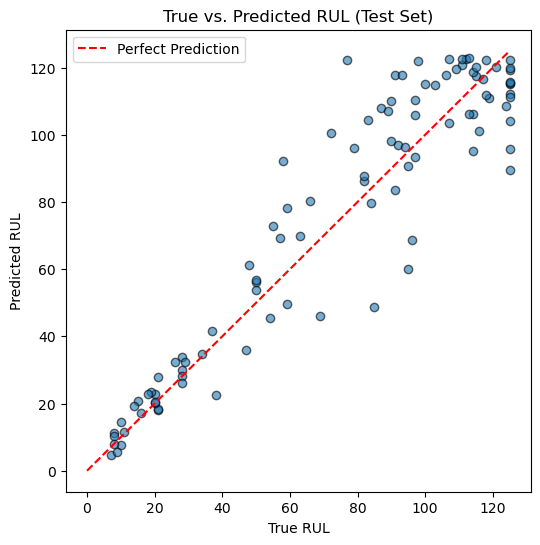

In [35]:
plt.figure(figsize=(6, 6))                                          # square figure so the diagonal reference line looks proportional

plt.scatter(y_test, test_preds, alpha=0.6, edgecolor="k")           # each point = one test engine: true RUL vs predicted RUL

max_val = max(y_test.max(), test_preds.max())                        # find the axis range that covers both true and predicted values
plt.plot([0, max_val], [0, max_val], "r--", label="Perfect Prediction")   # y = x line: if a point sits exactly on this line, the prediction was perfect

plt.xlabel("True RUL")                                                # x-axis: ground-truth RUL from NASA
plt.ylabel("Predicted RUL")                                           # y-axis: model's prediction
plt.title("True vs. Predicted RUL (Test Set)")                        # chart title
plt.legend()                                                          # show the "Perfect Prediction" line label
plt.show()                                                            # render the plot

The model **performs best at low RUL values** **(true RUL < 60)** — points cluster tightly around the diagonal, meaning the **model reliably recognizes engines close to failure**, where degradation signals in the sensors are strongest. Predictions also cluster correctly near the RUL cap (≈120–125) for healthy engines, showing the model has learned the capped target well.

The largest errors appear in the mid-range (true RUL ≈ 60–120), where several points fall noticeably off the diagonal — some engines are under-predicted, others over-predicted. This is expected: **in this range, sensor degradation is still gradual and less distinct**, making it harder for the model to pinpoint an exact remaining life. Overall, the scatter confirms the model captures the general degradation trend well, with the most reliable predictions occurring closest to end-of-life — arguably the **most operationally important region for maintenance decisions.**

## **19 - Streamlit Dasboard**


In [36]:
!pip install streamlit plotly -q

In [37]:
import os, json
import joblib

os.makedirs("artifacts", exist_ok=True)

torch.save(model.state_dict(), "artifacts/model.pt")   # trained model weights
with open("artifacts/model_config.json", "w") as f:
    json.dump({"n_features": len(feature_cols), "hidden_size": 64, "num_layers": 1}, f)

joblib.dump(scaler, "artifacts/scaler.pkl")   # fitted RobustScaler

last_cycle = test_df.groupby("unit")["cycle"].max().reset_index()
last_cycle.columns = ["unit", "last_cycle"]

fleet_summary = pd.DataFrame({
    "unit": sorted(test_df["unit"].unique()),
    "predicted_RUL": np.round(test_preds, 1),
    "true_RUL": y_test,
}).merge(last_cycle, on="unit")

def bucket(rul):
    if rul < 30: return "Critical"
    elif rul < 80: return "Warning"
    else: return "Healthy"

fleet_summary["status"] = fleet_summary["predicted_RUL"].apply(bucket)
fleet_summary = fleet_summary.sort_values("predicted_RUL").reset_index(drop=True)
fleet_summary.to_csv("artifacts/fleet_summary.csv", index=False)

test_df.to_csv("artifacts/test_sensor_history.csv", index=False)   # raw sensor history for trend charts
print("Artifacts saved.")

Artifacts saved.


In [38]:
# app.py — Aircraft Engine Health Monitor (FD001 RUL project)
# Run with: streamlit run app.py

import json
import numpy as np
import pandas as pd
import streamlit as st
import torch
import torch.nn as nn
import joblib
import plotly.graph_objects as go

st.set_page_config(page_title="RUL Monitor", page_icon="🛩️", layout="wide")

# ---------- color palette ----------
NAVY_DARK, NAVY_MID, NAVY_LIGHT = "#0B1F3A", "#1D3459", "#2C4570"
ICE_MUTED = "#C7D3EA"
AMBER, AMBER_DARK, AMBER_BG = "#F2A93B", "#C98A0E", "#FFF4E2"
RED, RED_BG = "#d03b3b", "#FBEAE8"
GREEN, GREEN_BG = "#0ca30c", "#E7F3EC"
TEXT_MUTED, BG_PAGE = "#6B7785", "#F8FAFD"

STATUS_COLORS = {"Critical": (RED, RED_BG), "Warning": (AMBER_DARK, AMBER_BG), "Healthy": (GREEN, GREEN_BG)}
STATUS_LABELS = {"Critical": "Critical", "Warning": "Monitor", "Healthy": "Healthy"}

# ---------- inject CSS ----------
st.markdown(f"""
<style>
    .stApp {{ background-color: {BG_PAGE}; }}
    section[data-testid="stSidebar"] {{ background-color: {NAVY_DARK}; }}
    section[data-testid="stSidebar"] * {{ color: {ICE_MUTED} !important; }}
    .page-eyebrow {{ color: {AMBER_DARK}; font-weight: 700; font-size: 12.5px; letter-spacing: .08em; text-transform: uppercase; }}
    .page-title {{ color: {NAVY_DARK}; font-size: 28px; font-weight: 800; margin: 0 0 2px 0; }}
    .page-sub {{ color: {TEXT_MUTED}; font-size: 14.5px; margin-bottom: 18px; }}
    .metric-card {{ border-radius: 14px; padding: 16px 18px; border: 1px solid #E2E7ED; }}
    .m-value {{ font-size: 30px; font-weight: 800; color: {NAVY_DARK}; }}
    .m-label {{ font-size: 13px; font-weight: 700; color: {NAVY_MID}; margin-top: 2px; }}
    .m-caption {{ font-size: 11.5px; color: {TEXT_MUTED}; margin-top: 2px; }}
    .status-pill {{ display: inline-block; padding: 3px 10px; border-radius: 999px; font-size: 12px; font-weight: 700; }}
</style>
""", unsafe_allow_html=True)


# ---------- model class — MUST match your notebook's RULLSTM exactly ----------
class RULLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_size, num_layers=num_layers, batch_first=True)
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, c_n) = self.lstm(x)
        return self.head(h_n[-1]).squeeze(-1)


SENSOR_LABELS = {
    'sensor_2': ("T30", "Total Temperature at HPC Outlet", "°R"),
    'sensor_3': ("T50", "Total Temperature at LPT Outlet", "°R"),
    'sensor_4': ("P2", "Pressure at Fan Inlet", "psia"),
    'sensor_7': ("Nf", "Physical Fan Speed", "rpm"),
    'sensor_8': ("Nc", "Physical Core Speed", "rpm"),
    'sensor_9': ("epr", "Engine Pressure Ratio", "-"),
    'sensor_11': ("phi", "Ratio of Fuel Flow to Ps30", "pps/psi"),
    'sensor_12': ("NRf", "Corrected Fan Speed", "rpm"),
    'sensor_13': ("NRc", "Corrected Core Speed", "rpm"),
    'sensor_14': ("BPR", "Bypass Ratio", "-"),
    'sensor_15': ("farB", "Burner Fuel-Air Ratio", "-"),
    'sensor_17': ("Nf_dmd", "Demanded Fan Speed", "rpm"),
    'sensor_20': ("W32", "LPT Coolant Bleed", "lbm/s"),
    'sensor_21': ("sensor_21", "Sensor 21 Measurement", "units"),
}
PROOF_SENSORS = ["sensor_12", "sensor_4", "sensor_11"]  # default sensor selection


# ---------- cached loaders — swap these paths for wherever you saved your artifacts ----------
@st.cache_resource
def load_model():
    with open("artifacts/model_config.json") as f:
        cfg = json.load(f)
    model = RULLSTM(n_features=cfg["n_features"], hidden_size=cfg["hidden_size"], num_layers=cfg["num_layers"])
    model.load_state_dict(torch.load("artifacts/model.pt", map_location="cpu"))
    model.eval()
    return model


@st.cache_data
def load_fleet_summary():
    return pd.read_csv("artifacts/fleet_summary.csv")   # unit, predicted_RUL, true_RUL, last_cycle, status


@st.cache_data
def load_sensor_history():
    return pd.read_csv("artifacts/test_sensor_history.csv")   # unit, cycle, sensor_2, sensor_3, ...


model = load_model()
fleet = load_fleet_summary()
history = load_sensor_history()


# ---------- sidebar navigation ----------
with st.sidebar:
    st.markdown("### ✈️ RUL Monitor")
    st.caption("NASA C-MAPSS · FD001")
    view = st.radio("Navigate", ["Fleet Overview", "Engine Detail"], label_visibility="collapsed")


# ---------- shared: fleet table renderer ----------
def render_fleet_table(df):
    header_style = "text-align:center; padding:10px; font-weight:700; text-transform:uppercase; font-size:12.5px; color:#1D3459; border-bottom:2px solid #E2E7ED;"
    rows_html = ""
    for _, r in df.iterrows():
        color, bg = STATUS_COLORS.get(r["status"], (TEXT_MUTED, "#EEF1F5"))
        label = STATUS_LABELS.get(r["status"], r["status"])
        rows_html += f"""
        <tr>
            <td style="text-align:center; padding:10px; border-bottom:1px solid #E2E7ED;">{int(r['unit'])}</td>
            <td style="text-align:center; padding:10px; border-bottom:1px solid #E2E7ED;">{int(np.floor(r['predicted_RUL']))}</td>
            <td style="text-align:center; padding:10px; border-bottom:1px solid #E2E7ED;">
                <span style="color:{color}; background:{bg}; font-weight:700; padding:3px 12px; border-radius:999px;">{label}</span>
            </td>
        </tr>"""
    html = f"""
    <div style="max-height:460px; overflow-y:auto; border:1px solid #E2E7ED; border-radius:10px;">
    <table style="width:100%; border-collapse:collapse; background:white;">
        <thead style="position:sticky; top:0; background:#F8FAFD;">
            <tr><th style="{header_style}">Engine</th><th style="{header_style}">Predicted RUL</th><th style="{header_style}">Status</th></tr>
        </thead>
        <tbody>{rows_html}</tbody>
    </table>
    </div>"""
    st.markdown(html, unsafe_allow_html=True)


# ---------- Fleet Overview page ----------
def fleet_overview():
    st.markdown("<div class='page-title' style='text-align:center; font-size:34px;'>✈ AIRCRAFT ENGINE HEALTH MONITOR</div>", unsafe_allow_html=True)
    st.markdown("<br>", unsafe_allow_html=True)

    counts = fleet["status"].value_counts()
    cols = st.columns(4)
    cards = [
        ("All Engines", str(len(fleet)), "Full fleet", NAVY_MID, "#EEF1F5"),
        ("Service Now", str(int(counts.get("Critical", 0))), "RUL under 30 cycles", RED, RED_BG),
        ("Monitor", str(int(counts.get("Warning", 0))), "RUL 30–80 cycles", AMBER_DARK, AMBER_BG),
        ("Healthy", str(int(counts.get("Healthy", 0))), "RUL over 80 cycles", GREEN, GREEN_BG),
    ]
    for col, (label, value, caption, color, bg) in zip(cols, cards):
        col.markdown(f"""<div class="metric-card" style="background:{bg};">
            <div class="m-value" style="color:{color};">{value}</div>
            <div class="m-label">{label}</div><div class="m-caption">{caption}</div></div>""", unsafe_allow_html=True)

    filter_choice = st.segmented_control("Filter", ["All", "Critical", "Monitor", "Healthy"], default="All", label_visibility="collapsed") or "All"
    FILTER_TO_RAW = {"All": "All", "Critical": "Critical", "Monitor": "Warning", "Healthy": "Healthy"}
    raw_filter = FILTER_TO_RAW[filter_choice]
    table = fleet.copy() if raw_filter == "All" else fleet[fleet["status"] == raw_filter].copy()
    render_fleet_table(table)


# ---------- Engine Detail page ----------
def engine_detail():
    st.markdown("<div class='page-eyebrow'>Engine Detail</div>", unsafe_allow_html=True)
    engine_id = st.selectbox("Select engine", options=fleet["unit"].tolist(), format_func=lambda u: f"Engine #{u}")
    row = fleet[fleet["unit"] == engine_id].iloc[0]
    color, bg = STATUS_COLORS[row["status"]]
    status_label = STATUS_LABELS[row["status"]]
    rul_val = row["predicted_RUL"]

    st.markdown(f"<div class='page-title'>Engine #{engine_id}</div>", unsafe_allow_html=True)
    st.markdown(f"<span class='status-pill' style='color:{color}; background:{bg};'>{status_label}</span> "
                f"<span style='color:{TEXT_MUTED};'>&nbsp;&nbsp;Last observed at cycle {int(row['last_cycle'])}</span>", unsafe_allow_html=True)

    left, right = st.columns([1, 2])

    with left:
        max_scale = 130
        fig = go.Figure(data=[go.Pie(
            values=[rul_val, max(max_scale - rul_val, 0)],
            hole=0.72,
            marker=dict(colors=[color, "#EEF1F5"]),
            textinfo="none", sort=False, direction="clockwise", showlegend=False,
        )])
        fig.add_annotation(
            text=f"{int(np.floor(rul_val))}<br><span style='font-size:12px; color:#6B7785;'>cycles remaining</span>",
            x=0.5, y=0.5, showarrow=False, font=dict(size=30, color=NAVY_DARK),
        )
        fig.update_layout(height=240, margin=dict(l=10, r=10, t=10, b=10), showlegend=False)
        st.plotly_chart(fig, use_container_width=True)

        available_sensors = [c for c in history.columns if c.startswith("sensor_")]
        selected_sensor = st.selectbox(
            "Choose a sensor to plot",
            options=available_sensors,
            index=available_sensors.index(PROOF_SENSORS[0]) if PROOF_SENSORS[0] in available_sensors else 0,
            format_func=lambda s: f"{s.upper()} ({SENSOR_LABELS.get(s, (s, s, ''))[0]})",
        )

    with right:
        eng_hist = history[history["unit"] == engine_id].sort_values("cycle")
        short_code, full_name, unit = SENSOR_LABELS.get(selected_sensor, (selected_sensor, selected_sensor, ""))

        fig2 = go.Figure()
        fig2.add_trace(go.Scatter(x=eng_hist["cycle"], y=eng_hist[selected_sensor], mode="lines",
                                   line=dict(color=NAVY_LIGHT, width=2)))
        fig2.update_layout(
            title=dict(text=f"{selected_sensor.upper()} ({short_code}) — {full_name} over Cycle", x=0.5, xanchor="center"),
            xaxis_title="<b>Cycle</b>",
            yaxis_title=f"<b>{full_name} [{unit}]</b>" if unit else f"<b>{full_name}</b>",
            height=340, margin=dict(l=55, r=20, t=60, b=45),
        )
        st.plotly_chart(fig2, use_container_width=True)

        # trend alert for Critical AND Monitor engines only — not Healthy
        if row["status"] in ("Critical", "Warning"):
            slope = np.polyfit(eng_hist["cycle"], eng_hist[selected_sensor], 1)[0]
            direction = "rising" if slope > 0 else "falling"
            alert_color, alert_bg = STATUS_COLORS[row["status"]]
            st.markdown(f"""
            <div style="background:{alert_bg}; border-radius:10px; padding:12px 16px; margin-top:4px;">
                <b style="color:{alert_color};">⚠ Trend Alert:</b>
                <span style="color:{NAVY_DARK};"> {selected_sensor.upper()} readings are {direction} over the observed cycles.</span>
            </div>
            """, unsafe_allow_html=True)


# ---------- route to the selected page ----------
if view == "Fleet Overview":
    fleet_overview()
else:
    engine_detail()

Overwriting app.py
